importing

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import IPython.display as ipd
from IPython.display import Audio

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Embedding, LSTM, BatchNormalization,GRU, Input, Flatten, Dropout, Activation, Conv1D, MaxPooling1D, AveragePooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

print("Done - TensorFlow version:", tf.__version__)

Done - TensorFlow version: 2.20.0


organizng files into specific folder

In [ ]:
import os
import shutil

def organize_crema_by_actor(source_dir, destination_dir):
    emotion_map = {
        'ANG': 'angry',
        'HAP': 'happy',
        'NEU': 'neutral',
        'SAD': 'sad'
    }
    
    if not os.path.exists(source_dir):
        print(f"Error: Source directory not found at {source_dir}")
        return

    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)
        
    files = os.listdir(source_dir)
    count = 0
    
    for file in files:
        if file.endswith('.wav'):
            parts = file.split('_')
            
            if len(parts) >= 3:
                actor_id = parts[0]
                emotion_code = parts[2]
                
                if emotion_code in emotion_map:
                    actor_folder = os.path.join(destination_dir, f"Actor_{actor_id}")
                    
                    if not os.path.exists(actor_folder):
                        os.makedirs(actor_folder)
                    
                    shutil.copy(os.path.join(source_dir, file), 
                                os.path.join(actor_folder, file))
                    count += 1
                            
    print(f"Success! Organized {count} files into actor-specific folders.")

source_path = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\crema-D\AudioWAV"
dest_path = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\crema-D\clean audio"

organize_crema_by_actor(source_path, dest_path)

Success! Organized 4900 files into actor-specific folders.


In [ ]:
import os
import shutil

def organize_tess_final(source_dir, destination_dir):
   
    target_emotions = ['angry', 'happy', 'happiness', 'sad', 'neutral']
    
    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)

    folder_count = 0
    file_count = 0
    
    for folder_name in os.listdir(source_dir):
        folder_path = os.path.join(source_dir, folder_name)
        
        if os.path.isdir(folder_path):
         
            parts = folder_name.split('_')
            if len(parts) >= 2:
                actor_name = parts[0].upper() 
                emotion_in_folder = parts[1].lower()
                
                if emotion_in_folder in target_emotions:
                    actor_dest_folder = os.path.join(destination_dir, f"Actor_{actor_name}")
                    if not os.path.exists(actor_dest_folder):
                        os.makedirs(actor_dest_folder)
                    
                    for file_name in os.listdir(folder_path):
                        if file_name.endswith('.wav'):
                            shutil.copy(os.path.join(folder_path, file_name), 
                                        os.path.join(actor_dest_folder, file_name))
                            file_count += 1
                    folder_count += 1

    print(f"Success! Processed {folder_count} TESS folders and copied {file_count} files.")

source_tess = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\tess\audioWAV"
dest_tess = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\tess\clean audio"

organize_tess_final(source_tess, dest_tess)

Success! Processed 8 TESS folders and copied 1600 files.


In [ ]:
import os
import shutil

def organize_savee_deep_scan(source_dir, destination_dir):
    if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)

    file_count = 0
    
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if not file.endswith('.wav'):
                continue
            
            parts = file.split('_')
            if len(parts) < 2:
                continue
            
            actor_name = parts[0].upper()       
            emotion_code = parts[1][0].lower()  
            second_char = parts[1][1].lower() if len(parts[1]) > 1 else ""
            
            is_target = False
            if emotion_code in ['a', 'h', 'n']:
                is_target = True
            elif emotion_code == 's' and second_char != 'a':
                is_target = True
            
            if not is_target:
                continue
            
            dest_actor_folder = os.path.join(destination_dir, f"Actor_{actor_name}")
            if not os.path.exists(dest_actor_folder):
                os.makedirs(dest_actor_folder)
            
            shutil.copy(os.path.join(root, file),
                        os.path.join(dest_actor_folder, file))
            file_count += 1
                            
    print(f"SAVEE Success! Organized {file_count} files into actor folders.")


source_savee = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\savee\SAVEE"
dest_savee = r"C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\data\raw_audio\savee\clean audio"

organize_savee_deep_scan(source_savee, dest_savee)

SAVEE Success! Organized 300 files into actor folders.


# Integration

In [6]:
!pip install azure-storage-blob

  Using cached azure_storage_blob-12.28.0-py3-none-any.whl.metadata (26 kB)
  Using cached azure_core-1.38.2-py3-none-any.whl.metadata (48 kB)
  Using cached isodate-0.7.2-py3-none-any.whl.metadata (11 kB)
Using cached azure_storage_blob-12.28.0-py3-none-any.whl (431 kB)
Using cached azure_core-1.38.2-py3-none-any.whl (217 kB)
Using cached isodate-0.7.2-py3-none-any.whl (22 kB)


In [ ]:
from azure.storage.blob import BlobServiceClient
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
container_name = "wav-files"

blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service_client.get_container_client(container_name)


def get_df_from_blob_dataset(prefix):
    emotions = []
    file_paths = []

    blobs = container_client.list_blobs(name_starts_with=prefix)

    for blob in blobs:
        if blob.name.endswith(".wav"):
            
            filename = blob.name.split("/")[-1]
            parts = filename.split('-')

            if len(parts) >= 3:
                emotion = parts[2].lower()
                emotions.append(emotion)
                file_paths.append(blob.name)

    return pd.DataFrame({
        'Emotions': emotions,
        'Path': file_paths
    })


ravdess_df = get_df_from_blob_dataset("RAVDESS/")
crema_df   = get_df_from_blob_dataset("CREMAD/")
tess_df    = get_df_from_blob_dataset("TESS/")
savee_df   = get_df_from_blob_dataset("SAVEE/")

data_path = pd.concat(
    [ravdess_df, crema_df, tess_df, savee_df],
    axis=0
)

data_path.reset_index(drop=True, inplace=True)

data_path.to_csv("data_path.csv", index=False)

print(data_path.head())
print("-" * 30)
print(data_path.Emotions.value_counts())

  Emotions                                          Path
0    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup0.wav
1    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup1.wav
2    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup2.wav
3    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup3.wav
4    angry  RAVDESS/Actor_01/RAVDESS-01-Angry-2-dup0.wav
------------------------------
Emotions
angry      1923
happy      1923
sad        1923
neutral    1703
Name: count, dtype: int64


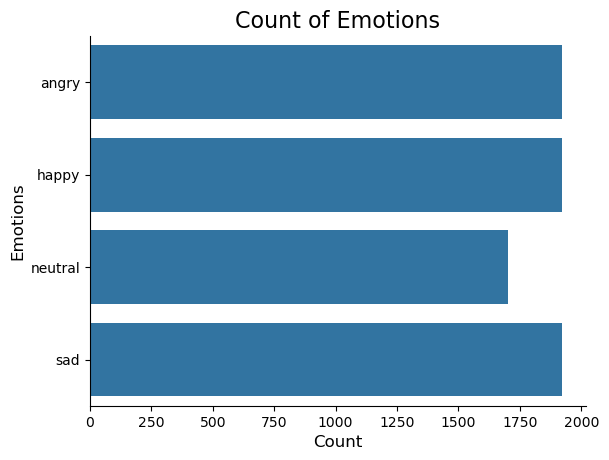

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.title('Count of Emotions', size=16)
sns.countplot(data_path.Emotions)
plt.ylabel('Emotions', size=12)
plt.xlabel('Count', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

# Data Augmentation

In [ ]:
import os
import pandas as pd
import numpy as np
import librosa
import warnings
import time
import io
from azure.storage.blob import BlobServiceClient

warnings.filterwarnings('ignore')

df = pd.read_csv("data_path.csv")


CONNECTION_STRING = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
CONTAINER_NAME = "wav-files"

if not CONNECTION_STRING:
    raise ValueError("⚠️ לא נמצא Connection String. ודא שהגדרת את משתנה הסביבה AZURE_STORAGE_CONNECTION_STRING")

blob_service_client = BlobServiceClient.from_connection_string(CONNECTION_STRING)

# Data Augmentation
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)


# Feature Extraction of 30 features using MFCC algo
def extract_features(data, sr):
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean


def get_features(path):
    try:
        clean_path = path.replace('\\', '/')
        
        blob_client = blob_service_client.get_blob_client(container=CONTAINER_NAME, blob=clean_path)
        
        download_stream = blob_client.download_blob()
        audio_file = io.BytesIO(download_stream.readall())
        
        data, sr = librosa.load(audio_file, duration=2.5, offset=0.6)
        
        #extracting and augmanting each file 
        res1 = extract_features(data, sr)
        res2 = extract_features(noise(data), sr)
        res3 = extract_features(stretch(data), sr)
        res4 = extract_features(shift(data), sr)
        res5 = extract_features(pitch(data, sr), sr)
        
        return [res1, res2, res3, res4, res5]
        
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None


X, Y = [], []  # X- list of vector for each file , y- real emotion of each file 

print(f"מתחיל לעבד {len(df)} קבצים מתוך Azure (מאובטח). התהליך ייקח זמן, קח קפה...")
start_time = time.time()

for index, row in df.iterrows():
    path = row['Path']
    emotion = row['Emotions']
    
    features = get_features(path)
    
    if features is not None:
        for ele in features:
            X.append(ele)
            Y.append(emotion)
            
    if (index + 1) % 100 == 0:
        print(f"עובדו {index + 1}/{len(df)} קבצים מהענן...")

end_time = time.time()
print(f"✅ סיום! זמן ריצה: {round((end_time - start_time)/60, 2)} דקות.")


Features_df = pd.DataFrame(X)
Features_df['Labels'] = Y

Features_df.to_csv("features_ready_for_model.csv", index=False)
print(f"הנתונים נשמרו בהצלחה. סך הכל דגימות לאימון: {len(Features_df)}")

מתחיל לעבד 7472 קבצים מתוך Azure (מאובטח). התהליך ייקח זמן, קח קפה...
עובדו 100/7472 קבצים מהענן...
עובדו 200/7472 קבצים מהענן...
עובדו 300/7472 קבצים מהענן...
עובדו 400/7472 קבצים מהענן...
עובדו 500/7472 קבצים מהענן...
עובדו 600/7472 קבצים מהענן...
עובדו 700/7472 קבצים מהענן...
עובדו 800/7472 קבצים מהענן...
עובדו 900/7472 קבצים מהענן...
עובדו 1000/7472 קבצים מהענן...
עובדו 1100/7472 קבצים מהענן...
עובדו 1200/7472 קבצים מהענן...
עובדו 1300/7472 קבצים מהענן...
עובדו 1400/7472 קבצים מהענן...
עובדו 1500/7472 קבצים מהענן...
עובדו 1600/7472 קבצים מהענן...
עובדו 1700/7472 קבצים מהענן...
עובדו 1800/7472 קבצים מהענן...
עובדו 1900/7472 קבצים מהענן...
עובדו 2000/7472 קבצים מהענן...
עובדו 2100/7472 קבצים מהענן...
עובדו 2200/7472 קבצים מהענן...
עובדו 2300/7472 קבצים מהענן...
עובדו 2400/7472 קבצים מהענן...
עובדו 2500/7472 קבצים מהענן...
עובדו 2600/7472 קבצים מהענן...
עובדו 2700/7472 קבצים מהענן...
עובדו 2800/7472 קבצים מהענן...
עובדו 2900/7472 קבצים מהענן...
עובדו 3000/7472 קבצים מהענן...
עובדו 310